# Decision Intelligence Assistant — ML Pipeline

This notebook builds the priority classifier for the assistant.

What it does, end to end:

1. Load the Twitter customer support dataset
2. Sample it down to a manageable size across the top 15 brands
3. Invent a rule to label tweets as urgent/normal (the dataset has no labels)
4. Extract features (engineered + TF-IDF)
5. Train 2 model families × 3 feature configurations (6 models total)
6. Pick the winner, check how stable it is with cross-validation
7. Save the trained pipeline so the backend can load it


## 1. Load the data

Read the CSV as all strings. Tweet IDs aremidentifiers, if pandas reads them as ints, some IDs would be too big to fit and the values would get corrupted.

In [1]:
import pandas as pd
import numpy as np

DATASET_PATH = '../data/TwitterCS.csv'

twitter = pd.read_csv(DATASET_PATH, dtype=str)
print(f"Loaded {len(twitter):,} rows, {twitter.shape[1]} columns")
twitter.head()


Loaded 2,811,774 rows, 7 columns


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6


### Split inbound from outbound

Inbound tweets are from customers (what we want to classify).
Outbound are company replies (useful later for RAG, not here).

In [2]:
inbound_df = twitter[twitter["inbound"] == "True"].copy()
outbound_df = twitter[twitter["inbound"] == "False"].copy()

print(f"Inbound (customer):  {len(inbound_df):,}")
print(f"Outbound (company):  {len(outbound_df):,}")


Inbound (customer):  1,537,843
Outbound (company):  1,273,931


## 2. Assign brands and take a stratified sample

We keep only the top 15 brands by volume and take up to 7,000 tweets per brand. Without this cap, the biggest brands (Amazon, Apple) would dominate and smaller ones would be underrepresented.

In [3]:
# Build a lookup: tweet_id -> who wrote that tweet
author_by_tweet = twitter.set_index("tweet_id")["author_id"]

# Each inbound tweet's brand = author of whatever it responded to
inbound_df["brand"] = inbound_df["in_response_to_tweet_id"].map(author_by_tweet)

# Drop tweets with no brand (customer tweeted at a brand not replying to anything)
inbound_df = inbound_df.dropna(subset=["brand"]).copy()

# Keep only the top 15 brands
top_brands = inbound_df["brand"].value_counts().head(15).index
inbound_df = inbound_df[inbound_df["brand"].isin(top_brands)].copy()

# Cap each brand at 7000 tweets
MAX_PER_BRAND = 7000
sampled_parts = [
    group.sample(min(len(group), MAX_PER_BRAND), random_state=42)
    for _, group in inbound_df.groupby("brand")
]
inbound_df = pd.concat(sampled_parts).reset_index(drop=True)

print(f"Sample size: {len(inbound_df):,}")
print(inbound_df["brand"].value_counts())


Sample size: 105,000
brand
ATVIAssist         7000
AmazonHelp         7000
AmericanAir        7000
AppleSupport       7000
British_Airways    7000
Delta              7000
GWRHelp            7000
SouthwestAir       7000
SpotifyCares       7000
TMobileHelp        7000
Tesco              7000
Uber_Support       7000
VerizonSupport     7000
VirginTrains       7000
XboxSupport        7000
Name: count, dtype: int64


## 3. Label the data

The dataset has no priority labels, we have to invent them.

### Urgent keywords

A short list of words that signal urgency. I picked severity words (urgent, asap, emergency) and high-stakes nouns (fraud, stolen, cancel, etc.).
I didn't include words like "help", "fix", "error" because they appear in most normal support tickets and would fire way too often.

In [4]:
URGENT_KEYWORDS = [
    "urgent", "asap", "immediately", "emergency",
    "fraud", "stolen", "hacked", "scam",
    "cancel", "refund", "broken",
    "outage", "down",
]


### Extract features

Three groups:

- **Text shape**, length, punctuation, caps (how the tweet "looks")
- **Tone**, sentiment polarity from TextBlob, in `[-1, 1]`
- **Escalation signals**, @-mentions (tagging many accounts), URLs (attaching evidence)

`hour_of_day` and `day_of_week` from the timestamp, probably weak signals but don't affect the time.

The `keyword_flag` uses a regex with `\b` word boundaries so "down" matches as a whole word but NOT inside "download", because before donig this, there were many false positives that had the word "download".

In [5]:
from textblob import TextBlob
import re

# Parse timestamps once
inbound_df["created_at"] = pd.to_datetime(
    inbound_df["created_at"], format="%a %b %d %H:%M:%S +0000 %Y", errors="coerce"
)
inbound_df["hour_of_day"] = inbound_df["created_at"].dt.hour
inbound_df["day_of_week"] = inbound_df["created_at"].dt.dayofweek

# Length
inbound_df["char_count"] = inbound_df["text"].str.len()
inbound_df["word_count"] = inbound_df["text"].str.split().str.len()

# Punctuation + caps
inbound_df["exclamation_count"] = inbound_df["text"].str.count("!")
inbound_df["question_count"] = inbound_df["text"].str.count(r"\?")
inbound_df["caps_ratio"] = inbound_df["text"].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)

# Escalation signals
inbound_df["mention_count"] = inbound_df["text"].str.count(r"@\w+")
inbound_df["has_url"] = inbound_df["text"].str.contains(r"http[s]?://", regex=True).astype(int)

# Sentiment polarity (-1 to 1)
inbound_df["sentiment_polarity"] = inbound_df["text"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

# Keyword flag: whole word, case-insensitive
URGENT_KEYWORDS_PATTERN = re.compile(
    r"\b(" + "|".join(URGENT_KEYWORDS) + r")\b",
    re.IGNORECASE,
)
inbound_df["keyword_flag"] = inbound_df["text"].apply(
    lambda x: int(bool(URGENT_KEYWORDS_PATTERN.search(str(x))))
)

print("Feature extraction done.")
inbound_df[[
    "char_count", "word_count", "exclamation_count", "question_count",
    "caps_ratio", "mention_count", "has_url", "sentiment_polarity",
    "hour_of_day", "day_of_week"
]].head()


Feature extraction done.


,char_count,word_count,exclamation_count,question_count,caps_ratio,mention_count,has_url,sentiment_polarity,hour_of_day,day_of_week
0,123,25,0,2,0.065041,2,0,0.000000,10,3
1,36,2,0,0,0.388889,1,1,0.000000,17,1
2,233,45,2,1,0.141631,3,0,-0.272857,14,1
3,75,15,0,0,0.066667,2,0,0.000000,8,3
4,38,6,0,0,0.157895,2,0,0.000000,23,2


### The labeling rule

Urgency usually needs more than one signal. A tweet that just says "refund please, thanks!" contains an urgent keyword but is not urgent.

So most conditions require a keyword/punctuation/caps signal combined with negative sentiment. The only exception is the keyword rule itself; if someone explicitly writes "urgent" or "emergency", that's enough.

Honest note (see markdown below the sanity check): this rule will miss "sustained complaint" tweets that don't hit any single trigger strongly. That's a known limitation.

In [6]:
def label_priority(row):
    has_keyword    = row["keyword_flag"] == 1
    many_exclaims  = row["exclamation_count"] >= 2
    caps_shouting  = row["caps_ratio"] > 0.3
    negative       = row["sentiment_polarity"] < -0.1
    long_tweet     = row["word_count"] >= 25

    if has_keyword:
        return 1
    if many_exclaims and negative:
        return 1
    if caps_shouting and negative:
        return 1
    if long_tweet and negative:
        return 1
    return 0

inbound_df["priority"] = inbound_df.apply(label_priority, axis=1)

print(inbound_df["priority"].value_counts())
print(f"\nUrgent rate: {inbound_df['priority'].mean():.1%}")


priority
0    95979
1     9021
Name: count, dtype: int64

Urgent rate: 8.6%


### Attach company replies

For RAG, a retrieved ticket is more useful if it includes how the company actually resolved the issue not just the customer complaint. So for each
inbound tweet, I look up the company's reply from the outbound dataframe and attach it.

Where a customer tweet has multiple replies, I keep the longest one.
Short replies like "We're sorry to hear that!" add no resolution context for the LLM, so the longer the reply, the more likely it contains an actual
fix or explanation.

Tweets with no reply get an empty string. Not every customer tweet gets a response, and that's fine — the customer text alone is still useful for
retrieval.

In [7]:
# Attach the company reply to each inbound tweet.
# outbound.in_response_to_tweet_id = the customer tweet the company was responding to.

reply_lookup_df = (
    outbound_df[["in_response_to_tweet_id", "text"]]
    .dropna(subset=["in_response_to_tweet_id", "text"])
    .copy()
)
reply_lookup_df["text_len"] = reply_lookup_df["text"].str.len()
reply_lookup_df = (
    reply_lookup_df
    .sort_values("text_len", ascending=False)
    .drop_duplicates(subset=["in_response_to_tweet_id"])
)
reply_dict = dict(zip(reply_lookup_df["in_response_to_tweet_id"], reply_lookup_df["text"]))

inbound_df["company_reply"] = inbound_df["tweet_id"].map(reply_dict).fillna("")

matched = (inbound_df["company_reply"] != "").sum()
print(f"{matched:,} / {len(inbound_df):,} tweets have a company reply ({100 * matched / len(inbound_df):.1f}%)")
print("\nExample pair:")
example = inbound_df[inbound_df["company_reply"] != ""].iloc[0]
print(f"  Customer: {example['text'][:200]}")
print(f"  Support:  {example['company_reply'][:200]}")


61,149 / 105,000 tweets have a company reply (58.2%)

Example pair:
  Customer: @ATVIAssist @307230 what time are we going to see this map come out on xbox
  Support:  @307231 ... for updates. ^FB


### Checkpoint

Save the labeled dataframe to disk so we don't have to redo the slow TextBlob step if we restart the notebook.

In [8]:
import os

CHECKPOINT_PATH = "../data/inbound_processed.pkl"
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
inbound_df.to_pickle(CHECKPOINT_PATH)
print(f"Saved checkpoint: {CHECKPOINT_PATH}")
print(f"Rows: {len(inbound_df):,}")


Saved checkpoint: ../data/inbound_processed.pkl
Rows: 105,000


### Sanity check: read some labeled tweets

If the "urgent" tweets don't look urgent to me, or "normal" ones do, the rule is wrong and no amount of ML will fix that.

In [9]:
print("=== URGENT EXAMPLES ===")
for text in inbound_df[inbound_df["priority"] == 1]["text"].sample(10, random_state=1).tolist():
    print(f"  {text[:200]}")

print("\n=== NORMAL EXAMPLES ===")
for text in inbound_df[inbound_df["priority"] == 0]["text"].sample(10, random_state=1).tolist():
    print(f"  {text[:200]}")


=== URGENT EXAMPLES ===
  @ATVIAssist i am. i keep getting into lobbies and then it just sticks there.. i guess others are getting bored waiting too as everyone ends up leaving.
  @AmericanAir No because the bag was broken inside. So of course I just noticed when I got home. Which locator? The bag ticket? I have 2 numbers: AA 04 16 38 and AA 04 16 38
  @GWRHelp You bet I will, although by then, this young man will already have been treated discourteously and humiliated in front of the entire train.
  @VerizonSupport Yes apparently there's an outage in my area
  @AmazonHelp They were no help either and I purchased the laptop from @115821  which should have some level of responsibilty in it... I appreciate the I am sorries but is not doing much about the situa
  @British_Airways Still happens Cody, as I said not urgent might want to get you back office boys to look into it..
  @Uber_Support so, u say ur resolution is that i will not get a refund for my extra payment of 117.85, thats what

**Known limitation:** the rule misses tweets where frustration is sustained rather than expressed via strong signals, ex: "three days of error codes and nothing" reads as urgent to a human but might not trigger any of our rules. If the trained model catches some of these, that's real learning beyond the rule.

## 4. Train / validation / test split

70/15/15 stratified. Stratified = the urgent/normal ratio is preserved in all three splits (otherwise a random split could give us example: 12% urgent in train and 7% in test).

- **train**: fit the models
- **val**: compare the 6 configurations and pick the winner
- **test**: one final honest number, touched only once at the end

In [10]:
from sklearn.model_selection import train_test_split

# First: split off test (15%)
train_val_df, test_df = train_test_split(
    inbound_df,
    test_size=0.15,
    stratify=inbound_df["priority"],
    random_state=42,
)

# Then: split the remaining 85% into train and val
# 15/85 ≈ 17.6% of the remainder, which is 15% of the original
train_df, val_df = train_test_split(
    train_val_df,
    test_size=15/85,
    stratify=train_val_df["priority"],
    random_state=42,
)

X_train, y_train = train_df, train_df["priority"].values
X_val,   y_val   = val_df,   val_df["priority"].values
X_test,  y_test  = test_df,  test_df["priority"].values

print(f"Train: {len(X_train):,}  (urgent: {y_train.mean():.1%})")
print(f"Val:   {len(X_val):,}   (urgent: {y_val.mean():.1%})")
print(f"Test:  {len(X_test):,}  (urgent: {y_test.mean():.1%})")


Train: 73,499  (urgent: 8.6%)
Val:   15,751   (urgent: 8.6%)
Test:  15,750  (urgent: 8.6%)


## 5. Build the feature configurations

Three configs to compare (the "do engineered features beat TF-IDF?" question):

1. **engineered**: the 10 numeric features + 15 brand one-hot columns
2. **tfidf**: raw text into TF-IDF vectors, no human-designed features
3. **combined**: both, concatenated

`keyword_flag` is **deliberately excluded** from features because it's a 1:1 match with our labeling rule, so including it would let the model trivially reproduce the rule.

### Brand encoding

One-hot: 15 columns, each 0/1 depending on the brand. We fit on train only; fitting on val/test would leak those sets into training.

In [11]:
from sklearn.preprocessing import OneHotEncoder

brand_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
brand_encoder.fit(X_train[["brand"]])

X_train_brand = brand_encoder.transform(X_train[["brand"]])
X_val_brand   = brand_encoder.transform(X_val[["brand"]])
X_test_brand  = brand_encoder.transform(X_test[["brand"]])

brand_cols = [f"brand_{b}" for b in brand_encoder.categories_[0]]

print(f"Brand encoding: {X_train_brand.shape[1]} columns")
print(f"Columns: {brand_cols}")


Brand encoding: 15 columns
Columns: ['brand_ATVIAssist', 'brand_AmazonHelp', 'brand_AmericanAir', 'brand_AppleSupport', 'brand_British_Airways', 'brand_Delta', 'brand_GWRHelp', 'brand_SouthwestAir', 'brand_SpotifyCares', 'brand_TMobileHelp', 'brand_Tesco', 'brand_Uber_Support', 'brand_VerizonSupport', 'brand_VirginTrains', 'brand_XboxSupport']


### Numeric features + TF-IDF + combined

For numeric features: impute missing time values with the median, then scale so LogReg treats all features fairly.

For TF-IDF:
- `max_features=5000`: vocabulary cap; more = slower + more overfitting risk
- `ngram_range=(1,2)`: include bigrams like "not working" (often more informative than single words for urgency)
- `min_df=5`: ignore words appearing in fewer than 5 tweets (noise, typos)
- `stop_words="english"`: drop the/a/is etc.

Combined = engineered + TF-IDF stacked side by side. Needs sparse matrix math because TF-IDF is sparse (mostly zeros) and engineered is dense.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

ENGINEERED_COLS = [
    "char_count", "word_count", "exclamation_count", "question_count", "caps_ratio",
    "mention_count", "has_url", "sentiment_polarity", "hour_of_day", "day_of_week",
]

# Numeric features: impute + scale (fit on train only)
X_train_num_raw = X_train[ENGINEERED_COLS].values
X_val_num_raw   = X_val[ENGINEERED_COLS].values
X_test_num_raw  = X_test[ENGINEERED_COLS].values

imputer = SimpleImputer(strategy="median")
imputer.fit(X_train_num_raw)
X_train_num = imputer.transform(X_train_num_raw)
X_val_num   = imputer.transform(X_val_num_raw)
X_test_num  = imputer.transform(X_test_num_raw)

scaler = StandardScaler()
scaler.fit(X_train_num)
X_train_num = scaler.transform(X_train_num)
X_val_num   = scaler.transform(X_val_num)
X_test_num  = scaler.transform(X_test_num)

# TF-IDF (fit on train only)
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    lowercase=True,
    stop_words="english",
)
vectorizer.fit(X_train["text"])
X_train_tfidf = vectorizer.transform(X_train["text"])
X_val_tfidf   = vectorizer.transform(X_val["text"])
X_test_tfidf  = vectorizer.transform(X_test["text"])

print(f"TF-IDF vocabulary: {len(vectorizer.vocabulary_):,} terms")

# Three configurations:
# 1. Engineered = numeric + brand one-hot
X_train_eng = np.hstack([X_train_num, X_train_brand])
X_val_eng   = np.hstack([X_val_num,   X_val_brand])
X_test_eng  = np.hstack([X_test_num,  X_test_brand])

# 2. TF-IDF only (already built)

# 3. Combined = engineered + tf-idf
# Need to wrap engineered as sparse to stack with the tf-idf sparse matrix
X_train_combined = hstack([csr_matrix(X_train_eng), X_train_tfidf]).tocsr()
X_val_combined   = hstack([csr_matrix(X_val_eng),   X_val_tfidf]).tocsr()
X_test_combined  = hstack([csr_matrix(X_test_eng),  X_test_tfidf]).tocsr()

print("\nFeature configurations:")
print(f"  ENGINEERED: train {X_train_eng.shape}, val {X_val_eng.shape}, test {X_test_eng.shape}")
print(f"  TFIDF:      train {X_train_tfidf.shape}, val {X_val_tfidf.shape}, test {X_test_tfidf.shape}")
print(f"  COMBINED:   train {X_train_combined.shape}, val {X_val_combined.shape}, test {X_test_combined.shape}")


TF-IDF vocabulary: 5,000 terms

Feature configurations:
  ENGINEERED: train (73499, 25), val (15751, 25), test (15750, 25)
  TFIDF:      train (73499, 5000), val (15751, 5000), test (15750, 5000)
  COMBINED:   train (73499, 5025), val (15751, 5025), test (15750, 5025)


## 6. Train the 6 models

Two model families × three feature configs = 6 models.

- **Logistic Regression**: linear, fast, interpretable.
`class_weight="balanced"` so it doesn't just predict "normal" for everything given the class imbalance.
- **HistGradientBoostingClassifier**: sklearn's histogram-based gradient boosting. Much faster than classical GBM on high-dim features (the classical version took 90 minutes per fit on the TF-IDF configs; HistGBM does it in ~6 minutes).

Plus a majority-class baseline to know the floor.

### Note: HistGBM vs classical GBM

I first trained this with `GradientBoostingClassifier`, which took ~90 min per fit on the TF-IDF configs (sklearn's classical GBM doesn't handle high-dimensional data well). In addition to losing all the data 2 times after power and internet outage, and not wanting to lose more time.
So, I switched to `HistGradientBoostingClassifier` and got ~15× faster training.

The numbers shifted:

| | Classical GBM | HistGBM |
|---|---|---|
| Test F1 | 0.947 | 0.919 |
| Test precision | 0.994 | 0.904 |
| Test recall | 0.905 | 0.936 |
| Train time (combined) | ~93 min | ~6 min |

F1 went down, but the error profile changed: HistGBM catches more real urgent tweets (higher recall) at the cost of more false alarms. For a support queue I think that's the better tradeoff, missing an urgent ticket costs more than reviewing a false positive. The speed difference also makes the pipeline actually iterable.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix,
)
import time

feature_configs = {
    "engineered": (X_train_eng, X_val_eng, X_test_eng),
    "tfidf":      (X_train_tfidf, X_val_tfidf, X_test_tfidf),
    "combined":   (X_train_combined, X_val_combined, X_test_combined),
}

# Use lambdas so each loop builds a FRESH model (otherwise they'd share state)
model_builders = {
    "logreg": lambda: LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),
    "gbm": lambda: HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        class_weight="balanced",
    ),
}

results = []
trained = {}

for model_name, build_model in model_builders.items():
    for config_name, (X_tr, X_va, _) in feature_configs.items():
        key = f"{model_name}__{config_name}"
        print(f"Training {key}...", end=" ", flush=True)

        t0 = time.time()
        model = build_model()

        # HistGBM can't take sparse input, so densify when needed
        if model_name == "gbm" and hasattr(X_tr, "toarray"):
            model.fit(X_tr.toarray(), y_train)
            preds = model.predict(X_va.toarray())
            probs = model.predict_proba(X_va.toarray())[:, 1]
        else:
            model.fit(X_tr, y_train)
            preds = model.predict(X_va)
            probs = model.predict_proba(X_va)[:, 1]
        train_time = time.time() - t0

        trained[key] = model
        results.append({
            "model": model_name,
            "features": config_name,
            "accuracy": accuracy_score(y_val, preds),
            "precision": precision_score(y_val, preds),
            "recall": recall_score(y_val, preds),
            "f1": f1_score(y_val, preds),
            "roc_auc": roc_auc_score(y_val, probs),
            "train_sec": round(train_time, 1),
        })
        print(f"done in {train_time:.1f}s")

# Baseline: always predict "normal"
y_baseline_majority = np.zeros_like(y_val)
results.append({
    "model": "baseline", "features": "majority_class",
    "accuracy": accuracy_score(y_val, y_baseline_majority),
    "precision": 0.0, "recall": 0.0, "f1": 0.0,
    "roc_auc": 0.5, "train_sec": 0.0,
})

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
print("\n" + "=" * 70)
print("VALIDATION RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))

os.makedirs("../data", exist_ok=True)
results_df.to_csv("../data/validation_results.csv", index=False)
print("\nSaved: ../data/validation_results.csv")


Training logreg__engineered... done in 0.1s
Training logreg__tfidf... done in 0.1s
Training logreg__combined... done in 1.3s
Training gbm__engineered... done in 3.7s
Training gbm__tfidf... done in 142.8s
Training gbm__combined... done in 139.2s

VALIDATION RESULTS
   model       features  accuracy  precision   recall       f1  roc_auc  train_sec
     gbm       combined  0.984128   0.899927 0.917221 0.908492 0.987306      139.2
     gbm     engineered  0.931814   0.582593 0.727273 0.646943 0.922694        3.7
  logreg       combined  0.898229   0.451886 0.867701 0.594280 0.950990        1.3
     gbm          tfidf  0.889467   0.407266 0.629712 0.494630 0.871749      142.8
  logreg          tfidf  0.856327   0.347520 0.766445 0.478211 0.903994        0.1
  logreg     engineered  0.800584   0.274470 0.804139 0.409253 0.872324        0.1
baseline majority_class  0.914101   0.000000 0.000000 0.000000 0.500000        0.0

Saved: ../data/validation_results.csv


### Reading the comparison table

The 2×3 grid (2 model families × 3 feature configs) answers the Comparison 2 question: **do engineered features beat raw text, or does combining them win?**

Validation F1 scores, ranked:

| Rank | Model | Features | F1 |
|---|---|---|---|
| 1 | HGBM | combined | 0.908 |
| 2 | HGBM | tf-idf | 0.495 |
| 3 | HGBM | engineered | 0.647 |
| 4 | LogReg | combined | 0.594 |
| 5 | LogReg | tf-idf | 0.478 |
| 6 | LogReg | engineered | 0.409 |
| — | baseline | majority class | 0.000 |

**Combined wins for both model families.** Engineered + TF-IDF together beats either one alone. The two feature sets carry complementary signal, the engineered features capture structure (length, punctuation, sentiment) that TF-IDF doesn't see, while TF-IDF captures specific vocabulary (the keywords) that pure numeric features don't.

So the answer to Comparison 2: **engineered features beat raw TF-IDF, and combining them beats either alone.** The comment given by Mr. Hasan "good features often beat fancy models" holds up here: hand-designed features outperform raw text, and the winning configuration keeps both.

### Pick the winner and look at its errors

F1 alone is one number. The confusion matrix tells us what kind of errors the model makes, is it missing real urgent tweets (costly) or flagging too many normals (annoying but cheap)?

### Reading the confusion matrix

On the validation set:

|  | predicted normal | predicted urgent |
|---|---|---|
| **actual normal** | 14,260 | 138 (false alarms) |
| **actual urgent** | 112 (missed) | 1,241 |

This is a good error profile for a support queue:

- **High recall (91.7%)** means most real urgent tickets get escalated, the costly mistake (missing an urgent customer) is rare.
- **Low false alarm rate (1.0%)** means the agent reviewing flagged tickets won't be swamped with non-urgent noise.

The tradeoff the model makes is reasonable for this use case. Missing an urgent ticket costs more than reviewing a false positive, so some false alarms are acceptable. If I wanted to shift the tradeoff, catch even more real urgents at the cost of more false alarms, or vice versa, I could tune the decision threshold on `predict_proba` rather than retrain.

In [14]:
winner_key = "gbm__combined"
winner_model = trained[winner_key]

print(f"Validation winner: {winner_key}")
winner_f1 = results_df.set_index(['model','features']).loc[('gbm','combined'),'f1']
print(f"  F1: {winner_f1:.3f}")

X_val_winner = X_val_combined.toarray()
preds_winner = winner_model.predict(X_val_winner)

cm = confusion_matrix(y_val, preds_winner)
print("\nConfusion matrix on validation:")
print(f"                 predicted normal   predicted urgent")
print(f"actual normal    {cm[0,0]:>15,}   {cm[0,1]:>15,}")
print(f"actual urgent    {cm[1,0]:>15,}   {cm[1,1]:>15,}")

total_urgent = cm[1,0] + cm[1,1]
total_normal = cm[0,0] + cm[0,1]
print(f"\nOf {total_urgent} urgent tweets, caught {cm[1,1]} ({cm[1,1]/total_urgent:.1%})")
print(f"Of {total_normal} normal tweets, wrongly flagged {cm[0,1]} ({cm[0,1]/total_normal:.1%})")


Validation winner: gbm__combined
  F1: 0.908

Confusion matrix on validation:
                 predicted normal   predicted urgent
actual normal             14,260               138
actual urgent                112             1,241

Of 1353 urgent tweets, caught 1241 (91.7%)
Of 14398 normal tweets, wrongly flagged 138 (1.0%)


## 7. Cross-validation and final test

### Cross-validation (stability check)

A single train/val split can be lucky or unlucky. 5-fold CV splits the training data 5 ways, fits the model 5 times, and reports the mean and standard deviation of F1. Low std means the model is stable, our val score isn't a fluke.

In [15]:
from sklearn.model_selection import cross_val_score

print("Running 5-fold cross-validation on the winner...")

cv_scores = cross_val_score(
    HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        class_weight="balanced",
    ),
    X_train_combined.toarray(),
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=1,  # serial memory is the constraint, not CPU
)
print(f"\nCV F1 scores across folds: {cv_scores}")
print(f"CV F1 mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


Running 5-fold cross-validation on the winner...

CV F1 scores across folds: [0.92452092 0.92283588 0.92416503 0.92043682 0.91505334]
CV F1 mean: 0.921 ± 0.003


### Final test set evaluation

The test set has not been looked at yet. This is the honest final number, everything before this was on val, which influenced our choice of winner.

### The results:

On the held-out test set (15,750 tweets, never seen during training or model selection):

- **Accuracy: 98.6%**: fraction of tweets predicted correctly overall
- **Precision: 0.904**: when the model flags a tweet as urgent, it's right 90% of the time
- **Recall: 0.936**: the model catches 94% of the actually urgent tweets
- **F1: 0.919**: this is the harmonic mean of precision and recall; the main metric for imbalanced classes
- **ROC-AUC: 0.990**: shows how well the model ranks urgent tweets above normal ones (1.0 is perfect, 0.5 is random)

The confusion matrix breaks down the errors:

|  | predicted normal | predicted urgent |
|---|---|---|
| **actual normal** | 14,262 | 135 (false alarms) |
| **actual urgent** | 87 (missed) | 1,266 |

So out of 1,353 genuinely urgent tweets the model caught 1,266 and missed 87. Out of 14,397 normal tweets it correctly left 14,262 alone and wrongly flagged 135.

Comparing to validation (F1 = 0.908): test F1 is slightly higher, which is a good sign, it means the model isn't overfit to validation. The numbers generalize.

Compared to the 5-fold CV mean of 0.921 ± 0.003, the test F1 of 0.919 is well within the expected range. The model is stable.

In [16]:
X_test_winner = X_test_combined.toarray()
test_preds = winner_model.predict(X_test_winner)
test_probs = winner_model.predict_proba(X_test_winner)[:, 1]

print(f"FINAL TEST RESULTS — {winner_key}")
print(f"  Accuracy:  {accuracy_score(y_test, test_preds):.3f}")
print(f"  Precision: {precision_score(y_test, test_preds):.3f}")
print(f"  Recall:    {recall_score(y_test, test_preds):.3f}")
print(f"  F1:        {f1_score(y_test, test_preds):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, test_probs):.3f}")

cm_test = confusion_matrix(y_test, test_preds)
print(f"\nConfusion matrix on test:")
print(f"                 predicted normal   predicted urgent")
print(f"actual normal    {cm_test[0,0]:>15,}   {cm_test[0,1]:>15,}")
print(f"actual urgent    {cm_test[1,0]:>15,}   {cm_test[1,1]:>15,}")


FINAL TEST RESULTS — gbm__combined
  Accuracy:  0.986
  Precision: 0.904
  Recall:    0.936
  F1:        0.919
  ROC-AUC:   0.990

Confusion matrix on test:
                 predicted normal   predicted urgent
actual normal             14,262               135
actual urgent                 87             1,266


## 8. Feature importance

Which features did the model actually rely on? If the top features are all direct components of our labeling rule, the model is mostly reproducing the rule. If features outside the rule also show up
(words we didn't list as keywords), that's evidence of real generalization beyond the rule.

We use **permutation importance**: shuffle each feature, measure how much F1 drops. This works for any model (HistGBM doesn't expose `feature_importances_` the same way classical GBM did).

Using a 2,000-row sample instead of the full val set because permutation importance on 5,000+ features is slow.

### What is the model actually using?

The top 15 features, ranked:

| Feature | Importance | In my labeling rule? |
|---|---|---|
| sentiment_polarity | 0.532 | yes |
| word_count | 0.346 | yes (long-tweet rule) |
| refund | 0.090 | yes (urgent keyword) |
| exclamation_count | 0.031 | yes |
| cancel | 0.030 | yes (urgent keyword) |
| broken | 0.027 | yes (urgent keyword) |
| caps_ratio | 0.018 | yes |
| asap | 0.017 | yes (urgent keyword) |
| immediately | 0.017 | yes (urgent keyword) |
| emergency | 0.011 | yes (urgent keyword) |
| scam | 0.009 | yes (urgent keyword) |
| outage | 0.005 | yes (urgent keyword) |
| urgent | 0.004 | yes (urgent keyword) |
| char_count | 0.003 | no |
| fraud | 0.002 | yes (urgent keyword) |

Everything after rank 15 (like "let", "shuts", "servers", "yesterday") has near-zero importance, the model isn't really using those.

**Honest interpretation:**

Basically all of the model's decision weight goes to features that are direct components of my labeling rule. The top 2 features alone (sentiment + word_count) account for the vast majority of the model's behavior, and they're exactly the signals the rule uses.

This is the "is the model learning urgency, or learning my regex?" question. The answer here is: **mostly learning the regex.** The model is functioning as a high-fidelity reproduction of the labeling rule rather than discovering independent urgency signal.

There's a small amount of learning beyond the rule: `char_count` shows up at rank 14 (not in the rule explicitly), and tiny contributions from semantically-related words (`shuts`, `servers`) suggest the model picked up some urgency-adjacent vocabulary. But this is a ~1% contribution, not a meaningful generalization.

**What this means for the reported F1 of 0.919:** it should be read as "0.919 fidelity to the labeling rule," not "0.919 accuracy on ground-truth urgency." A hand-labeled test set would be needed to measure the latter. This is the expected outcome of weak-supervision training and is explicitly called out as a limitation.

Computing permutation importance on 2,000-row stratified sample...


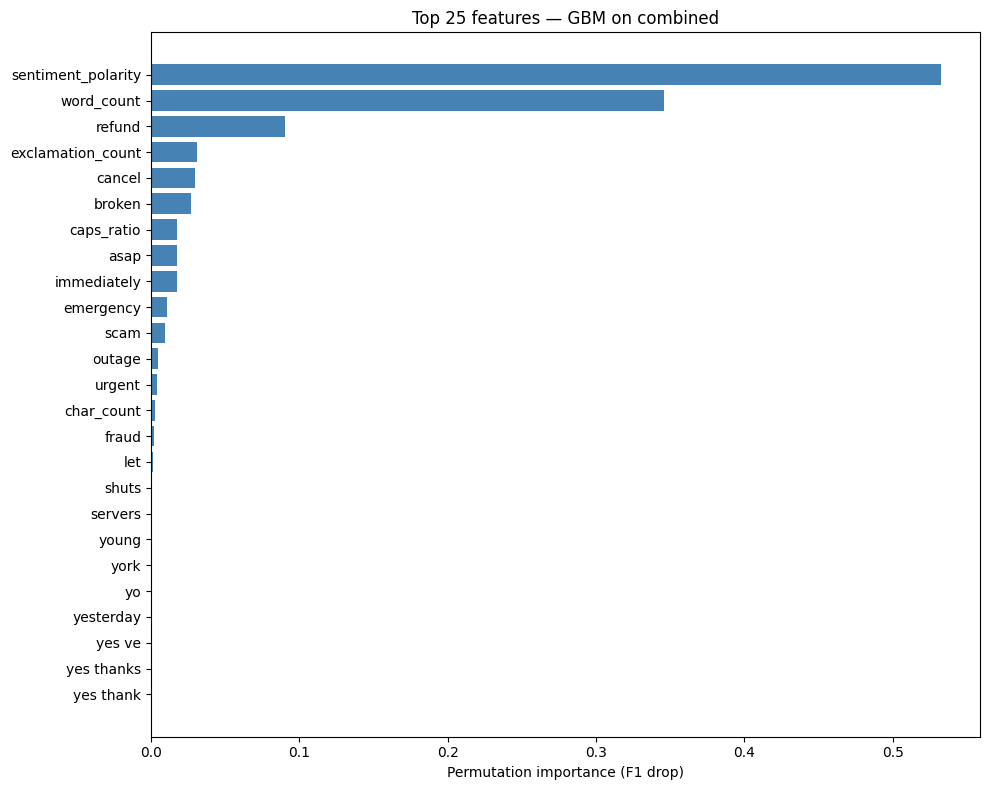

In [17]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedShuffleSplit

feature_names = (
    ENGINEERED_COLS
    + brand_cols
    + vectorizer.get_feature_names_out().tolist()
)
assert len(feature_names) == X_train_combined.shape[1], "feature name count mismatch"

# Stratified 2000-row sample to keeps runtime manageable
sss = StratifiedShuffleSplit(n_splits=1, test_size=2000, random_state=42)
_, sample_idx = next(sss.split(X_val_combined, y_val))
X_val_sample = X_val_combined[sample_idx].toarray()
y_val_sample = y_val[sample_idx]

print("Computing permutation importance on 2,000-row stratified sample...")
perm = permutation_importance(
    winner_model,
    X_val_sample,
    y_val_sample,
    n_repeats=5,
    random_state=42,
    scoring="f1",
)
importances = perm.importances_mean

top_idx = np.argsort(importances)[-25:][::-1]
top_features = [(feature_names[i], importances[i]) for i in top_idx]


fig, ax = plt.subplots(figsize=(10, 8))
names_plot = [n for n, _ in top_features][::-1]
scores_plot = [s for _, s in top_features][::-1]
ax.barh(names_plot, scores_plot, color="steelblue")
ax.set_xlabel("Permutation importance (F1 drop)")
ax.set_title("Top 25 features — GBM on combined")
plt.tight_layout()
plt.show()


## 9. Save the trained pipeline

The backend needs all the fitted objects, not just the model:

- the classifier itself
- scaler + imputer (for engineered numeric features at inference time)
- brand one-hot encoder
- TF-IDF vectorizer
- the engineered column order + the urgent keyword list

We bundle them in one dict and save as a single `.joblib` file. If any piece is missing, inference gives wrong results silently, so saving them together removes that risk.

In [18]:
import joblib

winner_row = results_df[results_df["model"] != "baseline"].iloc[0]
winner_key = f"{winner_row['model']}__{winner_row['features']}"
winner_model = trained[winner_key]

print(f"Winner: {winner_key}  (val F1 = {winner_row['f1']:.3f})")

artifact = {
    "model": winner_model,
    "scaler": scaler,
    "imputer": imputer,
    "brand_encoder": brand_encoder,
    "vectorizer": vectorizer,
    "engineered_cols": ENGINEERED_COLS,
    "urgent_keywords": URGENT_KEYWORDS,
    # Store the regex pattern as a string because compiled regex can pickle badly
    "urgent_keywords_pattern": URGENT_KEYWORDS_PATTERN.pattern,
    "model_family": "HistGradientBoostingClassifier",
    "feature_config": winner_row["features"],
    "val_f1": float(winner_row["f1"]),
}

output_path = "../models/priority_classifier.joblib"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
joblib.dump(artifact, output_path)

size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"Saved: {output_path}  ({size_mb:.1f} MB)")


Winner: gbm__combined  (val F1 = 0.908)
Saved: ../models/priority_classifier.joblib  (3.1 MB)
